<a href="https://colab.research.google.com/github/oabuhamed/metabolic-syndrome-prediction/blob/main/metabolic_syndrome_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Metabolic Syndrome Prediction project


In [ ]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
pd.set_option('display.max_columns', 100)

In [ ]:
#load the data
import pandas as pd
df = pd.read_csv('https://query.data.world/s/wiz6fht7uok2yy3odtbcsb4rvs6hib?dws=00000')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2401 entries, 0 to 2400
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   seqn               2401 non-null   int64  
 1   Age                2401 non-null   int64  
 2   Sex                2401 non-null   object 
 3   Marital            2193 non-null   object 
 4   Income             2284 non-null   float64
 5   Race               2401 non-null   object 
 6   WaistCirc          2316 non-null   float64
 7   BMI                2375 non-null   float64
 8   Albuminuria        2401 non-null   int64  
 9   UrAlbCr            2401 non-null   float64
 10  UricAcid           2401 non-null   float64
 11  BloodGlucose       2401 non-null   int64  
 12  HDL                2401 non-null   int64  
 13  Triglycerides      2401 non-null   int64  
 14  MetabolicSyndrome  2401 non-null   object 
dtypes: float64(5), int64(6), object(4)
memory usage: 281.5+ KB


,seqn,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,62161,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,No MetSyn
1,62164,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,No MetSyn
2,62169,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,No MetSyn
3,62172,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,No MetSyn
4,62177,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,No MetSyn


In [ ]:
#inspection of the data
df.shape

(2401, 15)

In [ ]:
# Perform some basic data exploration
print('\nFeature DataTypes:')
print(df.dtypes)
print('\n')

print('\nNumber of Missing Values per Feature:')
print(df.isnull().sum())
print('\n')

df.describe()


Feature DataTypes:
seqn                   int64
Age                    int64
Sex                   object
Marital               object
Income               float64
Race                  object
WaistCirc            float64
BMI                  float64
Albuminuria            int64
UrAlbCr              float64
UricAcid             float64
BloodGlucose           int64
HDL                    int64
Triglycerides          int64
MetabolicSyndrome     object
dtype: object



Number of Missing Values per Feature:
seqn                   0
Age                    0
Sex                    0
Marital              208
Income               117
Race                   0
WaistCirc             85
BMI                   26
Albuminuria            0
UrAlbCr                0
UricAcid               0
BloodGlucose           0
HDL                    0
Triglycerides          0
MetabolicSyndrome      0
dtype: int64




,seqn,Age,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides
count,2401.000000,2401.000000,2284.000000,2316.000000,2375.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000,2401.000000
mean,67030.674302,48.691795,4005.253940,98.307254,28.702189,0.154102,43.626131,5.489046,108.247813,53.369429,128.125364
std,2823.565114,17.632852,2954.032186,16.252634,6.662242,0.422780,258.272829,1.439358,34.820657,15.185537,95.322477
min,62161.000000,20.000000,300.000000,56.200000,13.400000,0.000000,1.400000,1.800000,39.000000,14.000000,26.000000
25%,64591.000000,34.000000,1600.000000,86.675000,24.000000,0.000000,4.450000,4.500000,92.000000,43.000000,75.000000
50%,67059.000000,48.000000,2500.000000,97.000000,27.700000,0.000000,7.070000,5.400000,99.000000,51.000000,103.000000
75%,69495.000000,63.000000,6200.000000,107.625000,32.100000,0.000000,13.690000,6.400000,110.000000,62.000000,150.000000
max,71915.000000,80.000000,9000.000000,176.000000,68.700000,2.000000,5928.000000,11.300000,382.000000,156.000000,1562.000000


In [ ]:
#drop the ID coumn
df = df.drop(columns='seqn')

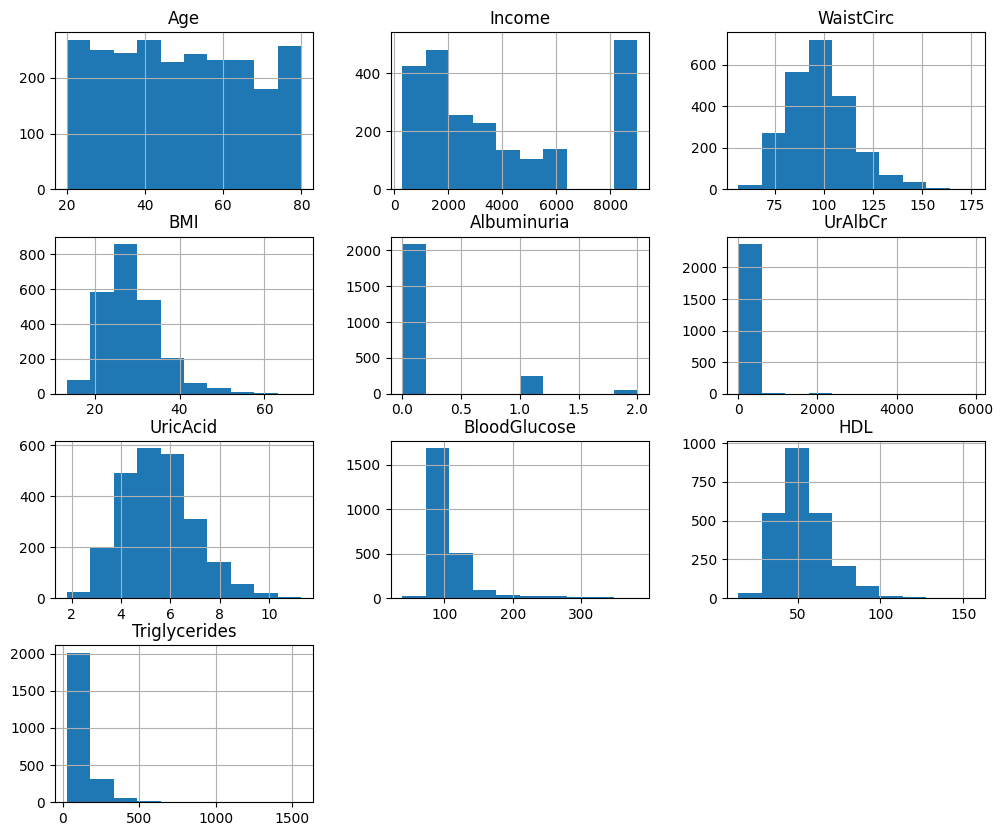

In [ ]:
df.hist(figsize=(12,10))
plt.show()

In [ ]:
#convert object features to integers
df['Sex'].value_counts()

,count
Sex,
Female,1211
Male,1190


In [ ]:
sex_dict = {"Male": 1,"Female": 0}
df['Sex'] = df['Sex'].replace(sex_dict)
df['Sex'].value_counts()

/tmp/ipykernel_287/1918010042.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace(sex_dict)


,count
Sex,
0,1211
1,1190


In [ ]:
df['Marital'].value_counts()

,count
Marital,
Married,1192
Single,498
Divorced,242
Widowed,166
Separated,95


In [ ]:
marital_dict = {'Married':0,'Single':1,'Divorced':2,'Widowed':3,'Separated':4}
df['Marital'] = df['Marital'].replace(marital_dict)
df['Marital'].value_counts()

/tmp/ipykernel_287/1395113322.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Marital'] = df['Marital'].replace(marital_dict)


,count
Marital,
0.0,1192
1.0,498
2.0,242
3.0,166
4.0,95


In [ ]:
df['Race'].value_counts()

,count
Race,
White,933
Black,548
Asian,349
Hispanic,257
MexAmerican,253
Other,61


In [ ]:
race_dict = {'White':0,'Black':1,'Asian':2,'Hispanic':3,'MexAmerican':4,'Other':5}
df['Race']=df['Race'].replace(race_dict)
df['Race'].value_counts()

/tmp/ipykernel_287/4195219604.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Race']=df['Race'].replace(race_dict)


,count
Race,
0,933
1,548
2,349
3,257
4,253
5,61


In [ ]:
df['MetabolicSyndrome'].value_counts()

,count
MetabolicSyndrome,
No MetSyn,1579
MetSyn,822


In [ ]:
metabolicSyndrome_dict = {'No MetSyn':0, 'MetSyn':1}
df['MetabolicSyndrome']= df['MetabolicSyndrome'].replace(metabolicSyndrome_dict)
df['MetabolicSyndrome'].value_counts()

/tmp/ipykernel_287/3813550984.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MetabolicSyndrome']= df['MetabolicSyndrome'].replace(metabolicSyndrome_dict)


,count
MetabolicSyndrome,
0,1579
1,822


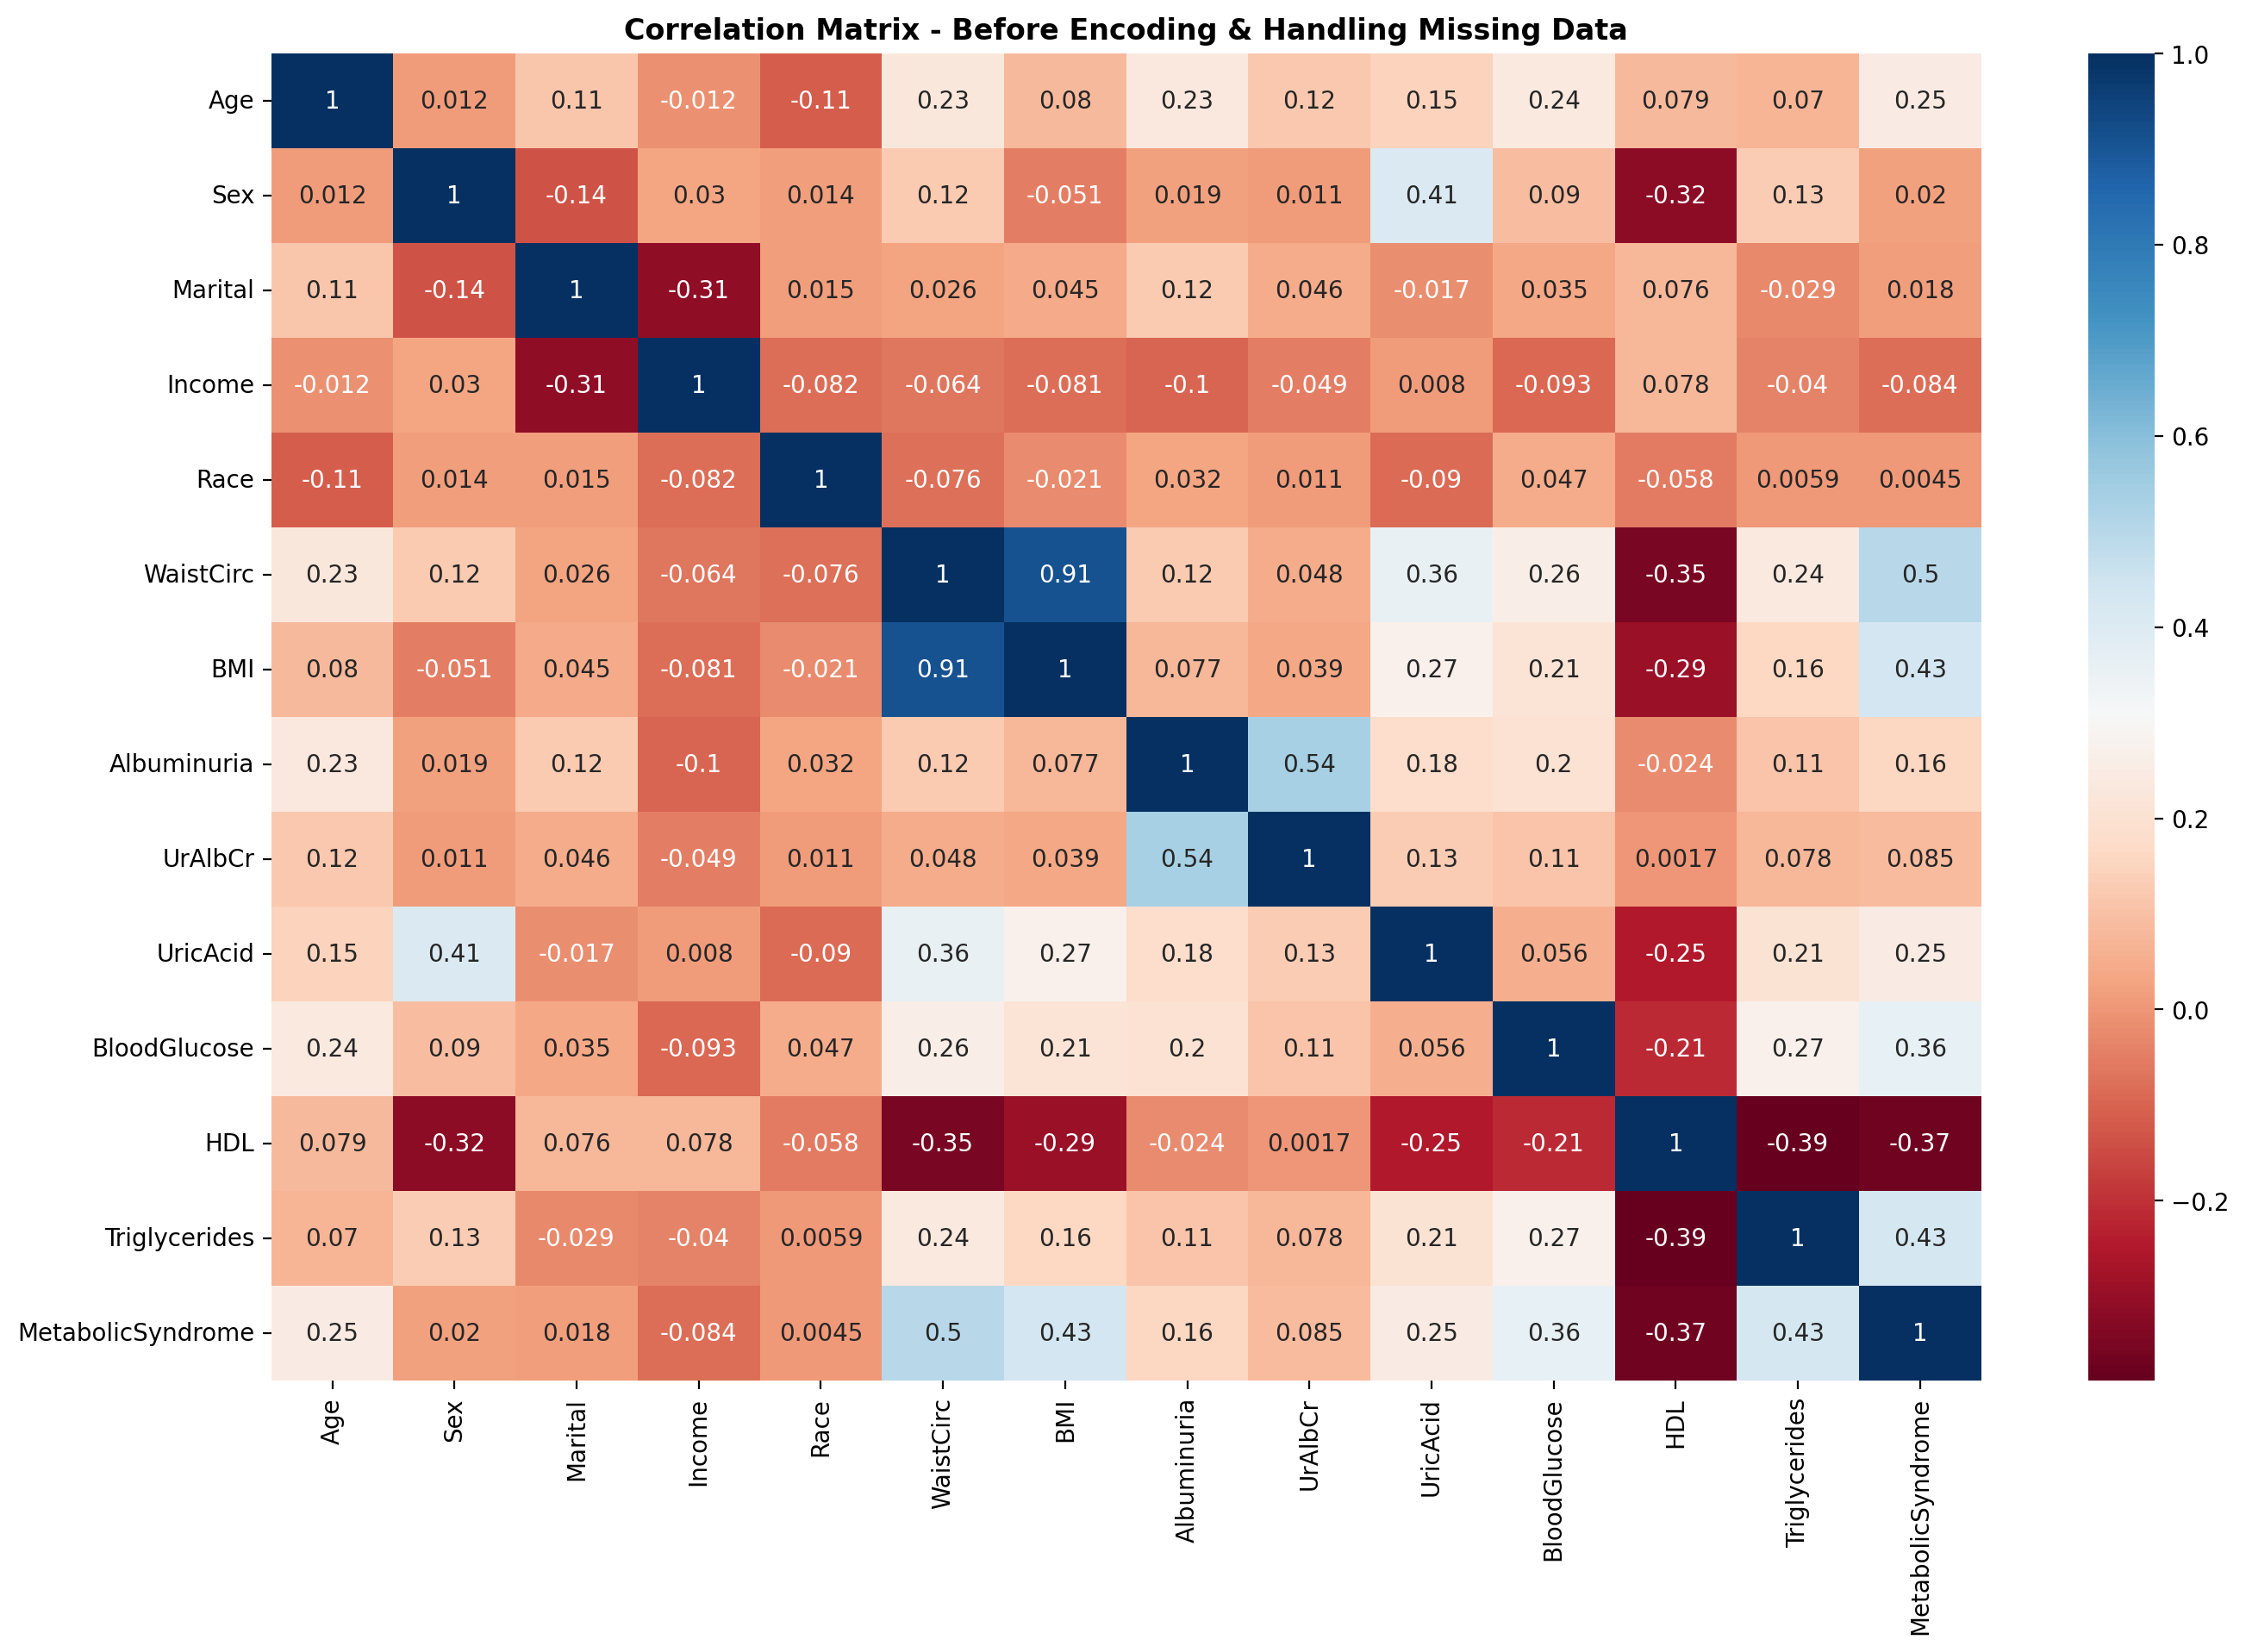

In [ ]:
plt.figure(figsize = (16,10), dpi=200)
ax = plt.axes()
sns.heatmap(df.corr(), annot = True, cmap='RdBu', ax=ax)
ax.set_title('Correlation Matrix - Before Encoding & Handling Missing Data', weight='bold')
plt.show()


The correlation heatmap shows the relationship between each feature and metabolic syndrome.
Waist circumference (0.50)
triglycerides (0.43)
BMI (0.43)
all show the strongest positive correlations with metabolic syndrome, indicating that higher values are associated with a higher prbapilty of the condition.
Blood glucose also shows a moderate positive relationship (0.36).
 HDL cholesterol shows a negative correlation (-0.37), meaning higher HDL levels are associated with lower risk.
 These findings align with the known clinical components of metabolic syndrome.

##Preprocessing the data

In [ ]:
#impute the missing valuse

- most frequent for Maretial Status

In [ ]:
marital_imputer = SimpleImputer(strategy="most_frequent")

df[["Marital"]] = marital_imputer.fit_transform(df[["Marital"]])

In [ ]:
df['Marital'].isna().sum()

np.int64(0)

-Median for BMI , WaistCirc,Inocome

In [ ]:
imputer = SimpleImputer(strategy="median")

df[["BMI","WaistCirc","Income"]] = imputer.fit_transform(df[["BMI","WaistCirc","Income"]])


In [ ]:
df[["BMI","WaistCirc","Income"]].isnull().sum()

,0
BMI,0
WaistCirc,0
Income,0


In [ ]:
df.isna().sum()

,0
Age,0
Sex,0
Marital,0
Income,0
Race,0
WaistCirc,0
BMI,0
Albuminuria,0
UrAlbCr,0
UricAcid,0


-Define the target and making the train and test split


In [ ]:
X = df.drop("MetabolicSyndrome", axis=1)
y = df["MetabolicSyndrome"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

-Train with random forest


In [ ]:
#fit the random forest model
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#make predictions
y_pred = rf.predict(X_test)

In [ ]:
#evaluate the model
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8818635607321131


In [ ]:
#classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       397
           1       0.86      0.78      0.82       204

    accuracy                           0.88       601
   macro avg       0.88      0.86      0.87       601
weighted avg       0.88      0.88      0.88       601



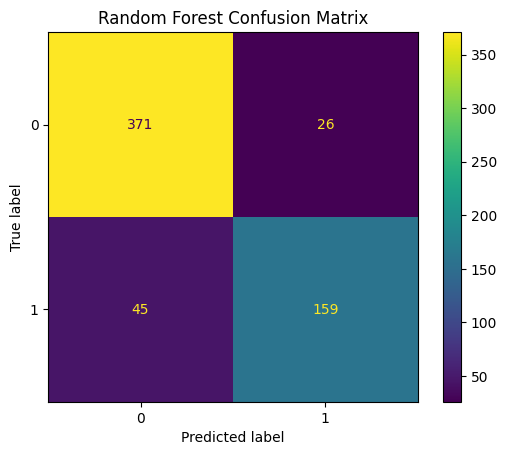

In [ ]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

plt.title("Random Forest Confusion Matrix")

plt.show()

-Permutation Imoprtance top 10 features

In [ ]:
#calculate permutation importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(rf,X_test,y_test,n_repeats=10,random_state=42)

In [ ]:
## make the mean importances into a series
permutation_importances = pd.Series(perm_importance['importances_mean'],index=X_test.columns,
                           name = 'permutation importance')
permutation_importances = permutation_importances.sort_values(ascending=False)
permutation_importances

,permutation importance
BloodGlucose,0.090017
Triglycerides,0.064060
WaistCirc,0.034942
HDL,0.020965
BMI,0.018968
Sex,0.014476
Age,0.011481
UrAlbCr,0.004326
Income,0.003161
Marital,0.001664


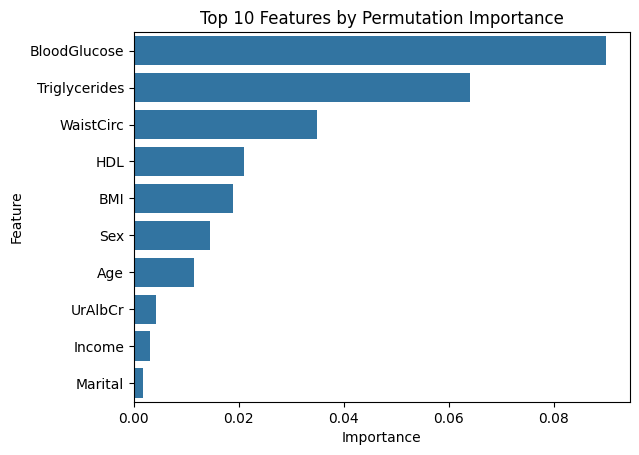

In [ ]:
#visualize the top 10 features using permutation importance

top10 = permutation_importances.head(10)

sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 Features by Permutation Importance")
plt.xlabel("Importance")
plt.ylabel("Feature");

-visualizing the highest 2 of  the top 10 features

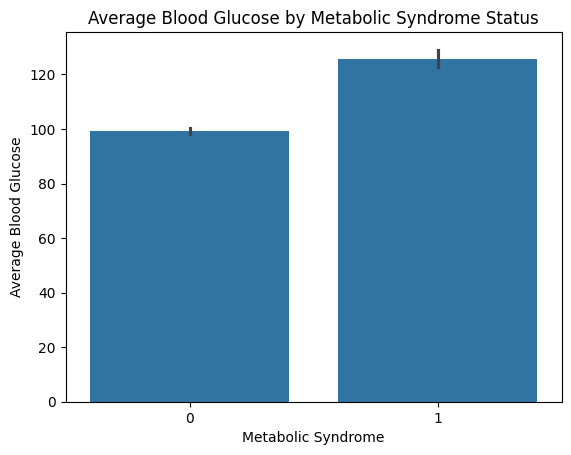

In [ ]:
#ploting the Avrage blood glucose
sns.barplot(x="MetabolicSyndrome",y="BloodGlucose",data=df)

plt.title("Average Blood Glucose by Metabolic Syndrome Status")
plt.xlabel("Metabolic Syndrome")
plt.ylabel("Average Blood Glucose");

### Exclusion
Individuals diagnosed with metabolic syndrome have higher average blood glucose levels compared to those without the condition. This pattern is expected because elevated blood glucose is one of the key metabolic abnormalities associated with metabolic syndrome.

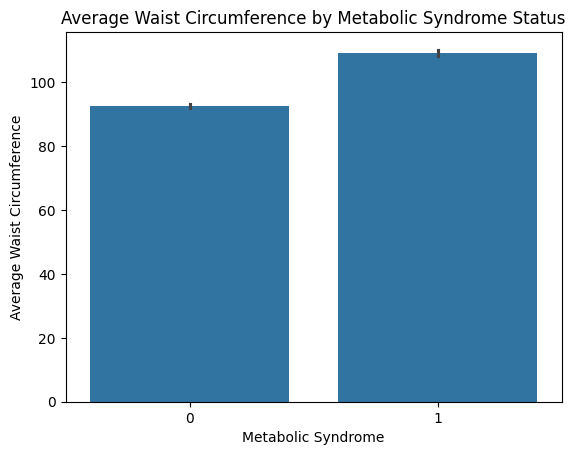

In [ ]:
sns.barplot(x="MetabolicSyndrome",y="WaistCirc",data=df)

plt.title("Average Waist Circumference by Metabolic Syndrome Status")
plt.xlabel("Metabolic Syndrome")
plt.ylabel("Average Waist Circumference");

### Exclusion

Patients with metabolic syndrome tend to have a larger waist circumference compared to individuals without the condition. This reflects the strong relationship between central obesity and metabolic syndrome.
